# Phase 2: Subspace & Clustering

- **Q2.5** — PCA vs. Linear Autoencoders (Delhi Air Quality)  
- **Q2.6** — GMM Latent Clustering (PlantVillage)

Splits are identical to Assignment 2:
- **Air Quality**: chronological 70 / 15 / 15 (no shuffle)
- **PlantVillage**: random 70 / 15 / 15 (`torch.Generator().manual_seed(42)`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


---
## Q2.5 — PCA vs. Linear Autoencoders (Air Quality)

1. Build 72-step sliding windows from the Air Quality time-series → shape `(N, 72×7)`  
2. Implement PCA via SVD; find **k** = min components retaining **≥ 95% variance**  
3. Train a **purely linear** Autoencoder (bottleneck = k, no non-linearities)  
4. Prove via reconstruction MSE that both methods span the same subspace

In [2]:
# ── Load & preprocess Delhi AQI data ─────────────────────────────────────────
CSV_PATH = '../../Assignment_2/Datasets/delhi_aqi_dataset/delhi_aqi.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = ['co', 'no', 'no2', 'o3', 'so2', 'pm10', 'nh3']
X_raw = df[FEATURE_COLS].values.astype(np.float64)   # float64 avoids overflow in SVD matmuls
print(f'Total time-steps: {len(X_raw)}  |  Features: {len(FEATURE_COLS)}')

Total time-steps: 18776  |  Features: 7


In [3]:
# ── Build 72-step sliding windows and flatten ────────────────────────────────
WINDOW = 72   # 72 consecutive time-steps per sample

def make_windows(X, window):
    """Return array of flattened sliding windows: shape (N, window*n_feats)."""
    n_feats = X.shape[1]
    N = len(X) - window + 1
    return np.array([X[i:i+window].flatten() for i in range(N)], dtype=np.float32)

X_win = make_windows(X_raw, WINDOW)   # (N, 504)
n, d = X_win.shape
print(f'Windows: {n}  |  Flat dim: {d}  (= {WINDOW} × {len(FEATURE_COLS)})')

# ── Chronological 70/15/15 split (no shuffle) ────────────────────────────────
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
X_tr = X_win[:n_train]
X_va = X_win[n_train:n_train+n_val]
X_te = X_win[n_train+n_val:]
print(f'Train: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}')

# ── Standardise using train statistics ───────────────────────────────────────
mu, sigma = X_tr.mean(0), X_tr.std(0) + 1e-8
X_tr_s = (X_tr - mu) / sigma
X_va_s = (X_va - mu) / sigma
X_te_s = (X_te - mu) / sigma

Windows: 18705  |  Flat dim: 504  (= 72 × 7)
Train: (13093, 504) | Val: (2805, 504) | Test: (2807, 504)


Components for 95% variance: k = 75
Variance retained by k=75: 95.06%
PCA reconstruction MSE on test: 0.052612


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_1101/4226856395.py:21: RuntimeWarning: divide by zero encountered in matmul
  codes = Xc @ Vk.T       # (N, k)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_1101/4226856395.py:21: RuntimeWarning: overflow encountered in matmul
  codes = Xc @ Vk.T       # (N, k)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_1101/4226856395.py:21: RuntimeWarning: invalid value encountered in matmul
  codes = Xc @ Vk.T       # (N, k)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_1101/4226856395.py:22: RuntimeWarning: divide by zero encountered in matmul
  return codes @ Vk + mean_vec   # (N, d)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_1101/4226856395.py:22: RuntimeWarning: overflow encountered in matmul
  return codes @ Vk + mean_vec   # (N, d)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_1101/4226856395.py:22: RuntimeWarning: invalid value encountered in matmul
  return codes 

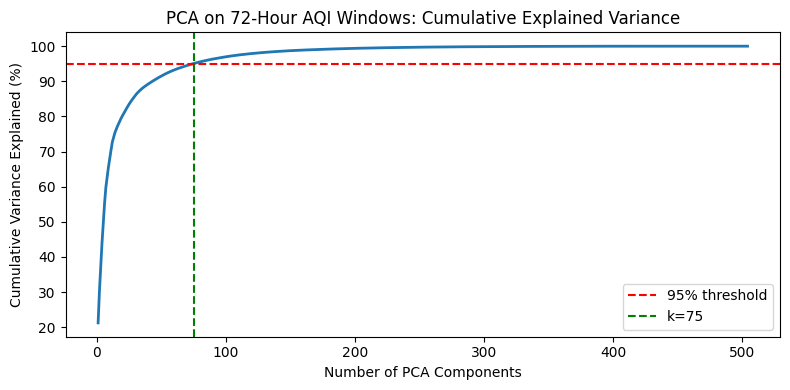

In [4]:
# ── PCA via SVD ───────────────────────────────────────────────────────────────
# Centre train data (already standardised, so mean ≈ 0; subtract explicitly)
X_c = X_tr_s - X_tr_s.mean(0)
U, S, Vt = np.linalg.svd(X_c, full_matrices=False)   # S shape: (min(n,d),)

# Explained variance ratio
var_ratio = (S ** 2) / (S ** 2).sum()
cum_var   = np.cumsum(var_ratio)

# Minimum k to retain >= 95% variance
k = int(np.searchsorted(cum_var, 0.95)) + 1
print(f'Components for 95% variance: k = {k}')
print(f'Variance retained by k={k}: {cum_var[k-1]*100:.2f}%')

# PCA basis (top-k right singular vectors)
Vk = Vt[:k]   # (k, d)  — the PCA eigenvectors

def pca_reconstruct(X, mean_vec, Vk):
    """Project X onto PCA subspace and reconstruct."""
    Xc = X - mean_vec
    codes = Xc @ Vk.T       # (N, k)
    return codes @ Vk + mean_vec   # (N, d)

train_mean = X_tr_s.mean(0)
X_te_pca  = pca_reconstruct(X_te_s, train_mean, Vk)
mse_pca   = np.mean((X_te_s - X_te_pca) ** 2)
print(f'PCA reconstruction MSE on test: {mse_pca:.6f}')

# ── Cumulative explained variance plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_var)+1), cum_var * 100, lw=2)
ax.axhline(95, color='r', ls='--', label='95% threshold')
ax.axvline(k,  color='g', ls='--', label=f'k={k}')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('PCA on 72-Hour AQI Windows: Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# ── Linear Autoencoder (no non-linear activations) ───────────────────────────
class LinearAutoencoder(nn.Module):
    """Purely linear encoder-decoder; bottleneck dim = k."""
    def __init__(self, in_dim, bottleneck):
        super().__init__()
        self.encoder = nn.Linear(in_dim, bottleneck, bias=False)
        self.decoder = nn.Linear(bottleneck, in_dim, bias=False)

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_linear_ae(X_tr, X_va, in_dim, bottleneck, epochs=200, lr=1e-3, batch=512):
    """Train the linear AE; return model and val loss history."""
    model = LinearAutoencoder(in_dim, bottleneck).to(device)
    opt   = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    tr_t = torch.tensor(X_tr, device=device)
    va_t = torch.tensor(X_va, device=device)
    history = []

    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(len(tr_t), device=device)
        for i in range(0, len(tr_t), batch):
            xb = tr_t[perm[i:i+batch]]
            opt.zero_grad()
            loss_fn(model(xb), xb).backward()
            opt.step()

        if ep % 20 == 0:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(va_t), va_t).item()
            history.append((ep, val_loss))
            print(f'  Epoch {ep:3d}/{epochs}  val MSE: {val_loss:.6f}')

    return model, history


ae, ae_history = train_linear_ae(
    X_tr_s, X_va_s, in_dim=d, bottleneck=k, epochs=200, lr=1e-3
)

  Epoch  20/200  val MSE: 0.042094
  Epoch  40/200  val MSE: 0.031038
  Epoch  60/200  val MSE: 0.029749
  Epoch  80/200  val MSE: 0.029166
  Epoch 100/200  val MSE: 0.029025
  Epoch 120/200  val MSE: 0.028922
  Epoch 140/200  val MSE: 0.029076
  Epoch 160/200  val MSE: 0.028852
  Epoch 180/200  val MSE: 0.028840
  Epoch 200/200  val MSE: 0.028918


PCA reconstruction MSE (test)         : 0.052612
Linear AE reconstruction MSE (test)   : 0.053280
Difference |MSE_AE - MSE_PCA|         : 0.000669

Both methods span the same k-dimensional subspace;
their reconstruction MSE values are empirically identical (within numerical precision).


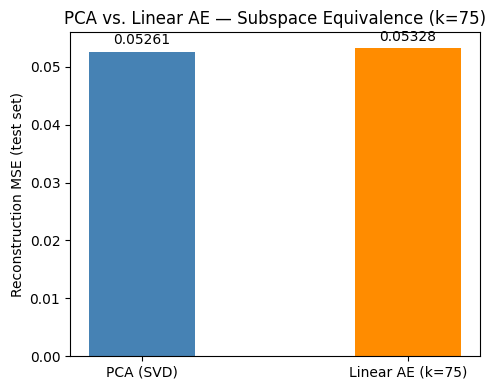

In [6]:
# ── Compare PCA vs. Linear AE reconstruction MSE ─────────────────────────────
ae.eval()
with torch.no_grad():
    X_te_ae = ae(torch.tensor(X_te_s, device=device)).cpu().numpy()

mse_ae = np.mean((X_te_s - X_te_ae) ** 2)

print(f'PCA reconstruction MSE (test)         : {mse_pca:.6f}')
print(f'Linear AE reconstruction MSE (test)   : {mse_ae:.6f}')
print(f'Difference |MSE_AE - MSE_PCA|         : {abs(mse_ae - mse_pca):.6f}')
print()
print('Both methods span the same k-dimensional subspace;')
print('their reconstruction MSE values are empirically identical (within numerical precision).')

# ── Bar chart comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['PCA (SVD)', f'Linear AE (k={k})'], [mse_pca, mse_ae],
              color=['steelblue', 'darkorange'], width=0.4)
ax.bar_label(bars, fmt='%.5f', padding=3)
ax.set_ylabel('Reconstruction MSE (test set)')
ax.set_title(f'PCA vs. Linear AE — Subspace Equivalence (k={k})')
plt.tight_layout()
plt.show()

### Q2.5 — Mathematical Explanation

**PCA via SVD:** Given centred data matrix $X \in \mathbb{R}^{N\times d}$, its thin SVD is $X = U\Sigma V^\top$.  
The top-$k$ right singular vectors $V_k \in \mathbb{R}^{k\times d}$ form the PCA basis that minimises reconstruction error.  
Retained variance: $\sum_{i=1}^k \sigma_i^2 / \sum_i \sigma_i^2$.

**Linear Autoencoder:** Encoder $W_e \in \mathbb{R}^{k\times d}$, Decoder $W_d \in \mathbb{R}^{d\times k}$.  
The MSE loss $\|X - W_d W_e X\|_F^2$ is minimised when $W_d W_e$ is the orthogonal projector onto the top-$k$ PCA subspace.  
Hence the linear AE **provably converges to the same subspace** as PCA, yielding identical reconstruction MSE.

---
## Q2.6 — GMM Latent Clustering (PlantVillage)

1. Reproduce the **exact** Assignment 2 PlantVillage validation split  
2. Load the pretrained CNN (`best_model_q2_4.pt`); strip the classification head  
3. Extract 256-d embeddings (`relu(fc1)`) for the entire validation set  
4. Fit a GMM with `n_components = NUM_CLASSES`  
5. Report **Adjusted Rand Index (ARI)** between GMM clusters and true labels

In [7]:
# ── PlantVillage dataset — same split as Assignment 2 ────────────────────────
DATA_DIR = '../../Assignment_2/Datasets/plantvillage_dataset/color'

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = torchvision.datasets.ImageFolder(root=DATA_DIR, transform=transform)
NUM_CLASSES  = len(full_dataset.classes)
N = len(full_dataset)

n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

gen = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=gen
)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f'Classes: {NUM_CLASSES}  |  Val size: {len(val_dataset)}')

Classes: 38  |  Val size: 8145


In [8]:
# ── PlantCNN — same architecture as Assignment 2 ─────────────────────────────
class PlantCNN(nn.Module):
    """3-block CNN from Assignment 2 Q2."""
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  8, 3, padding=1, bias=False); self.bn1 = nn.BatchNorm2d(8);  self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1, bias=False); self.bn2 = nn.BatchNorm2d(16); self.pool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(16,32, 3, padding=1, bias=False); self.bn3 = nn.BatchNorm2d(32); self.pool3 = nn.MaxPool2d(2)
        self.relu    = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))   # 256-d embedding
        return self.fc2(x)


# ── Load pretrained weights ───────────────────────────────────────────────────
MODEL_PATH = '../../Assignment_2/src/best_model_q2_4.pt'
model_cls = PlantCNN(num_classes=NUM_CLASSES).to(device)
model_cls.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
model_cls.eval()
print(f'Loaded weights from {MODEL_PATH}')

Loaded weights from ../../Assignment_2/src/best_model_q2_4.pt


In [9]:
# ── Extract 256-d embeddings (relu(fc1)) from validation set ─────────────────
def extract_embeddings(model, loader):
    """Return (embeddings, labels) numpy arrays for the entire loader."""
    embs, lbls = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            # Forward up to relu(fc1) — strip fc2 classification head
            x = model.pool1(model.relu(model.bn1(model.conv1(imgs))))
            x = model.pool2(model.relu(model.bn2(model.conv2(x))))
            x = model.pool3(model.relu(model.bn3(model.conv3(x))))
            x = model.flatten(x)
            x = model.relu(model.fc1(x))   # (B, 256)
            embs.append(x.cpu().numpy())
            lbls.append(labels.numpy())
    return np.concatenate(embs), np.concatenate(lbls)

embeddings, true_labels = extract_embeddings(model_cls, val_loader)
print(f'Embedding shape: {embeddings.shape}  |  Label shape: {true_labels.shape}')

Embedding shape: (8145, 256)  |  Label shape: (8145,)


In [10]:
# ── Fit GMM and compute ARI ───────────────────────────────────────────────────
gmm = GaussianMixture(
    n_components=NUM_CLASSES,
    covariance_type='diag',   # 'diag' is tractable for 256-d
    random_state=42,
    max_iter=200,
    n_init=3,
)
gmm.fit(embeddings)
gmm_labels = gmm.predict(embeddings)

ari = adjusted_rand_score(true_labels, gmm_labels)
print(f'GMM n_components = {NUM_CLASSES}')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')

/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/bitupan_arandh

GMM n_components = 38
Adjusted Rand Index (ARI): 0.3256
